In [1]:
import os, warnings, requests, zipfile, io
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from rasterstats import zonal_stats
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Create output folders
os.makedirs('data/shapefiles', exist_ok=True)
os.makedirs('data/chirps', exist_ok=True)
os.makedirs('data/worldpop', exist_ok=True)
os.makedirs('data/cattle', exist_ok=True)
os.makedirs('data/mpi', exist_ok=True)
os.makedirs('outputs/maps', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

print('Libraries imported and folders created!')

Libraries imported and folders created!


In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "rioxarray"])
print("✅ rioxarray installed")
!pip install netCDF4 h5netcdf
!pip install h5py

✅ rioxarray installed
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Create folders first
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs('outputs/maps', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

# Download Ethiopia Admin1 Boundaries
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_ETH.gpkg"
GADM_FILE = "data/raw/gadm41_ETH.gpkg"

if not os.path.exists(GADM_FILE):
    print("Downloading GADM Ethiopia GeoPackage (~15 MB)...")
    r = requests.get(GADM_URL, stream=True, timeout=120)
    with open(GADM_FILE, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("✅ Downloaded.")
else:
    print("✅ Already downloaded.")

# Read Admin1 layer
eth_adm1 = gpd.read_file(GADM_FILE, layer="ADM_ADM_1")
eth_adm1 = eth_adm1[["GID_1", "NAME_1", "geometry"]].copy()
eth_adm1.rename(columns={"NAME_1": "Region"}, inplace=True)
print(f"Regions found: {len(eth_adm1)}")
print(eth_adm1[["GID_1", "Region"]])

✅ Already downloaded.
Regions found: 11
       GID_1                           Region
0    ETH.1_1                      Addis Abeba
1    ETH.2_1                             Afar
2    ETH.3_1                           Amhara
3    ETH.4_1                 Benshangul-Gumaz
4    ETH.5_1                        Dire Dawa
5    ETH.6_1                  Gambela Peoples
6    ETH.7_1                    Harari People
7    ETH.8_1                           Oromia
8    ETH.9_1                           Somali
9   ETH.10_1  Southern Nations, Nationalities
10  ETH.11_1                           Tigray


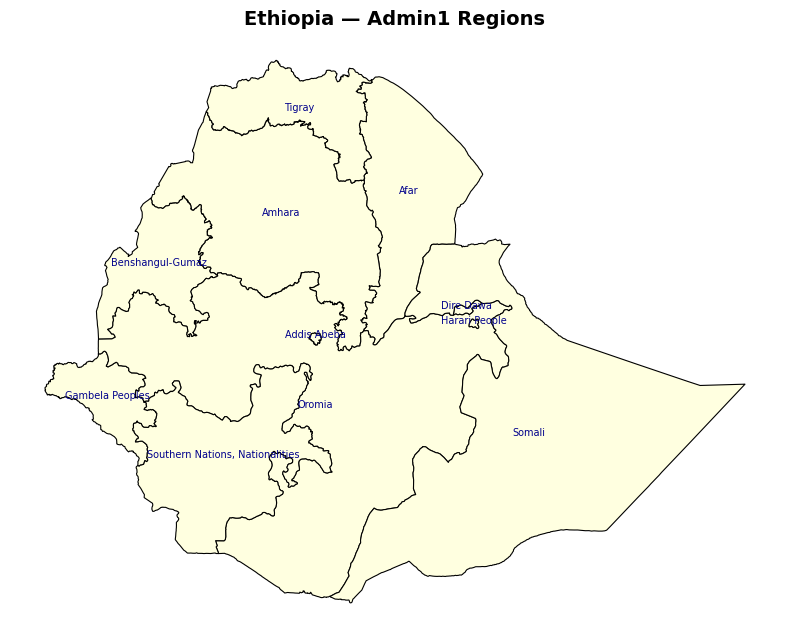

Base map saved!


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

eth_adm1.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=0.8)

# Label each region
for idx, row in eth_adm1.iterrows():
    ax.annotate(row['Region'],
                xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                fontsize=7, ha='center', color='darkblue')

ax.set_title('Ethiopia — Admin1 Regions', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/maps/ethiopia_admin1.png', dpi=150)
plt.show()
print('Base map saved!')

In [7]:
from tqdm import tqdm

# Ethiopia bounding box
ETH_BBOX = {'west': 32.9, 'east': 48.0, 'south': 3.4, 'north': 15.0}

# CHIRPS 0.25 degree daily global NetCDF files
CHIRPS_BASE = 'https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p25/'

YEARS = list(range(1991, 2026))  # 1991 to 2025

chirps_files = []

for year in tqdm(YEARS, desc='Downloading CHIRPS'):
    fname = f'chirps-v2.0.{year}.days_p25.nc'
    fpath = f'data/chirps/{fname}'
    chirps_files.append(fpath)

    if os.path.exists(fpath):
        continue  # Skip already downloaded

    url = CHIRPS_BASE + fname
    try:
        r = requests.get(url, stream=True, timeout=180)
        if r.status_code == 200:
            with open(fpath, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    f.write(chunk)
        else:
            print(f'Warning: {year} returned HTTP {r.status_code}')
    except Exception as e:
        print(f'Error downloading {year}: {e}')

chirps_files = [f for f in chirps_files if os.path.exists(f)]
print(f'\nDownloaded {len(chirps_files)} CHIRPS files out of 35 years.')


Downloaded 35 CHIRPS files out of 35 years.


In [8]:
import xarray as xr

print('Loading CHIRPS data for Ethiopia bounding box...')

ETH_BBOX = {'west': 32.9, 'east': 48.0, 'south': 3.4, 'north': 15.0}

all_precip = []

for fpath in tqdm(chirps_files, desc='Reading CHIRPS files'):
    ds = xr.open_dataset(fpath)
    
    # Get the precipitation variable name
    var = [v for v in ds.data_vars][0]
    
    # Clip to Ethiopia bounding box
    ds_eth = ds[var].sel(
        longitude=slice(ETH_BBOX['west'], ETH_BBOX['east']),
        latitude=slice(ETH_BBOX['south'], ETH_BBOX['north'])
    )
    all_precip.append(ds_eth.load())
    ds.close()

# Combine all years into one dataset
print('Concatenating all years...')
full_series = xr.concat(all_precip, dim='time')

print(f'Total days in dataset: {full_series.sizes["time"]}')
print(f'Grid size: {full_series.sizes["latitude"]} lat × {full_series.sizes["longitude"]} lon')
print('Done!')

Loading CHIRPS data for Ethiopia bounding box...


Reading CHIRPS files: 100%|████████████████████████████████████████████████████████████| 35/35 [00:10<00:00,  3.45it/s]

Concatenating all years...
Total days in dataset: 12784
Grid size: 46 lat × 60 lon
Done!


In [9]:
print('Applying wet-day threshold (>= 0.2 mm)...')

# Replace values below 0.2 mm with NaN (dry days — excluded)
wet_days = full_series.where(full_series >= 0.2)

# Compute 95th percentile at each pixel across all wet days
print('Computing 95th percentile at each grid point (this may take 2-3 minutes)...')
p95 = wet_days.quantile(0.95, dim='time', skipna=True)

print(f'Done!')
print(f'Min value: {float(p95.min()):.2f} mm')
print(f'Max value: {float(p95.max()):.2f} mm')
print(f'Mean value: {float(p95.mean()):.2f} mm')

Applying wet-day threshold (>= 0.2 mm)...
Computing 95th percentile at each grid point (this may take 2-3 minutes)...
Done!
Min value: 3.19 mm
Max value: 43.60 mm
Mean value: 21.33 mm


In [10]:
from rasterio.transform import from_bounds
import numpy as np

print('Saving hazard raster...')

p95_array = p95.values
lats = p95.latitude.values
lons = p95.longitude.values

transform = from_bounds(
    lons.min(), lats.min(), lons.max(), lats.max(),
    len(lons), len(lats)
)

with rasterio.open(
    'data/chirps/ethiopia_hazard_p95.tif', 'w',
    driver='GTiff',
    height=len(lats),
    width=len(lons),
    count=1,
    dtype='float32',
    crs='EPSG:4326',
    transform=transform,
    nodata=-9999
) as dst:
    arr = np.flipud(p95_array).astype('float32')
    arr[np.isnan(arr)] = -9999
    dst.write(arr, 1)

print('Hazard raster saved: data/chirps/ethiopia_hazard_p95.tif')

Saving hazard raster...
Hazard raster saved: data/chirps/ethiopia_hazard_p95.tif


In [71]:
from rasterstats import zonal_stats

print('Aggregating hazard to Admin1 regions...')

stats_hazard = zonal_stats(eth_adm1,
    'data/chirps/ethiopia_hazard_p95.tif',
    stats=['mean'],
    nodata=-9999,
    all_touched=True
)

eth_adm1['hazard_raw'] = [
    s['mean'] if s['mean'] is not None else np.nan
    for s in stats_hazard
]

print('Hazard per region:')
print(eth_adm1[['Region', 'hazard_raw']].sort_values('hazard_raw', ascending=False).to_string(index=False))

Aggregating hazard to Admin1 regions...
Hazard per region:
                         Region  hazard_raw
Southern Nations, Nationalities   27.259280
                         Oromia   26.325169
                    Addis Abeba   25.895206
                         Somali   25.067310
                         Amhara   24.522410
                         Tigray   21.549469
                Gambela Peoples   21.247582
               Benshangul-Gumaz   21.072759
                  Harari People   20.604380
                      Dire Dawa   19.777164
                           Afar   15.154066


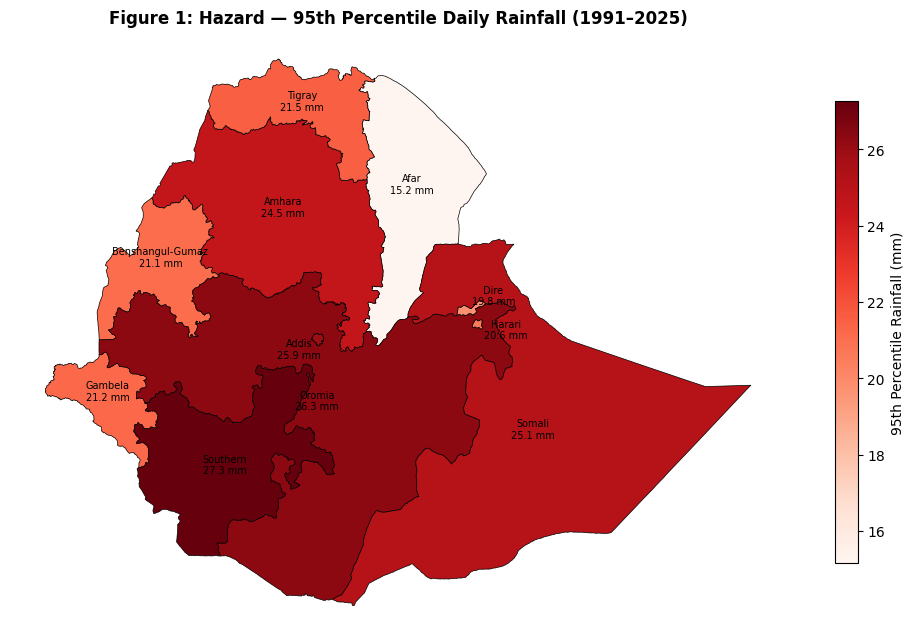

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

eth_adm1.plot(column='hazard_raw', ax=ax, cmap='Reds', legend=True,
              edgecolor='black', linewidth=0.5,
              legend_kwds={'label': '95th Percentile Rainfall (mm)', 'shrink': 0.6})

# Manual offsets for overlapping regions only
offsets = {
    'Dire Dawa':                       ( 0.5,  0.1),
    'Harari People':                   ( 0.6, -0.3),
    'Addis Abeba':                     (-0.4, -0.4),
    'Southern Nations, Nationalities': ( 0.0, -0.3),
}

for idx, row in eth_adm1.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ox, oy = offsets.get(row['Region'], (0, 0))
    ax.annotate(f"{row['Region'].split()[0]}\n{row['hazard_raw']:.1f} mm",
                xy=(x + ox, y + oy),
                fontsize=7, ha='center', color='black')

ax.set_title('Figure 1: Hazard — 95th Percentile Daily Rainfall (1991–2025)',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/maps/01_hazard_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import os, requests, rasterio

# WorldPop 2025 constrained 100m resolution — latest year
POP_URL = 'https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2025/ETH/v1/100m/constrained/eth_pop_2025_CN_100m_R2025A_v1.tif'
POP_PATH = 'data/worldpop/eth_pop_2025.tif'

print('Downloading WorldPop 2025 (100m resolution)...')
r = requests.get(POP_URL, stream=True, timeout=300)
print(f'Server response: {r.status_code}')

with open(POP_PATH, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024*1024):
        f.write(chunk)

size_mb = os.path.getsize(POP_PATH) / 1024 / 1024
print(f'Downloaded! File size: {size_mb:.1f} MB')

# Verify
with rasterio.open(POP_PATH) as src:
    print(f'Shape: {src.shape}')
    print(f'CRS: {src.crs}')
    print(f'Resolution: {src.res}')
print('WorldPop 2025 file valid!')

Server response: 200
Downloaded! File size: 152.0 MB
Shape: (13788, 18001)
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
WorldPop 2025 file valid!


In [27]:
import rasterio

POP_PATH = 'data/worldpop/eth_pop_2025.tif'

with rasterio.open(POP_PATH) as src:
    print(f'Shape: {src.shape}')
    print(f'CRS: {src.crs}')
    print(f'Resolution: {src.res}')
    print(f'Bounds: {src.bounds}')
    print(f'NoData: {src.nodata}')
    
import os
size_mb = os.path.getsize(POP_PATH) / 1024 / 1024
print(f'File size: {size_mb:.1f} MB')
print('WorldPop file is valid!')

Shape: (13788, 18001)
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Bounds: BoundingBox(left=32.99833248134, bottom=3.405000322379987, right=47.99916575467, top=14.895000276419987)
NoData: -99999.0
File size: 152.0 MB
WorldPop file is valid!


In [36]:
from rasterstats import zonal_stats
import numpy as np

print('Aggregating population to Admin1 regions...')

stats_pop = zonal_stats(
    eth_adm1,
    POP_PATH,
    stats=['sum'],
    nodata=-99999,
)

eth_adm1['pop_raw'] = [
    s['sum'] if s['sum'] is not None else 0
    for s in stats_pop
]

print('Population per region:')
print(eth_adm1[['Region', 'pop_raw']]
      .sort_values('pop_raw', ascending=False)
      .to_string(index=False))

Aggregating population to Admin1 regions...
Population per region:
                         Region      pop_raw
                         Oromia 5.409227e+07
Southern Nations, Nationalities 2.724373e+07
                         Amhara 2.628486e+07
                         Tigray 7.757356e+06
                         Somali 7.356134e+06
                    Addis Abeba 4.576825e+06
                           Afar 2.132712e+06
               Benshangul-Gumaz 2.035390e+06
                      Dire Dawa 7.536364e+05
                Gambela Peoples 6.766323e+05
                  Harari People 6.488810e+05


In [31]:
import os, requests, rasterio

# Direct download URL using fileId from Harvard Dataverse
CATTLE_URL = 'https://dataverse.harvard.edu/api/access/datafile/6769710'
CATTLE_PATH = 'data/cattle/eth_cattle.tif'

print('Downloading cattle raster...')
r = requests.get(
    CATTLE_URL, stream=True, timeout=300,
    headers={'User-Agent': 'Mozilla/5.0'}
)
print(f'Server response: {r.status_code}')

if r.status_code == 200:
    with open(CATTLE_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)
    size_mb = os.path.getsize(CATTLE_PATH) / 1024 / 1024
    print(f'Downloaded! File size: {size_mb:.1f} MB')
    
    # Verify
    with rasterio.open(CATTLE_PATH) as src:
        print(f'Shape: {src.shape}')
        print(f'CRS: {src.crs}')
        print(f'Resolution: {src.res}')
    print('Cattle file valid!')
else:
    print(f'Failed with status: {r.status_code}')

Server response: 200
Downloaded! File size: 5.9 MB
Shape: (2160, 4320)
CRS: EPSG:4326
Resolution: (0.08333333333333333, 0.08333333333333333)
Cattle file valid!


In [34]:
from rasterstats import zonal_stats
import numpy as np
import rasterio

print('Re-aggregating cattle to Admin1...')

with rasterio.open(CATTLE_PATH) as src:
    nodata_val = src.nodata

stats_cattle = zonal_stats(
    eth_adm1,
    CATTLE_PATH,
    stats=['sum'],
    nodata=nodata_val,  
)

eth_adm1['cattle_raw'] = [
    s['sum'] if s['sum'] is not None else 0
    for s in stats_cattle
]
eth_adm1['cattle_raw'] = eth_adm1['cattle_raw'].clip(lower=0)

print('Cattle per region:')
print(eth_adm1[['Region', 'cattle_raw']]
      .sort_values('cattle_raw', ascending=False)
      .to_string(index=False))

Re-aggregating cattle to Admin1...
Cattle per region:
                         Region   cattle_raw
                         Oromia 2.313215e+07
                         Amhara 1.460262e+07
Southern Nations, Nationalities 1.096687e+07
                         Tigray 3.509903e+06
                           Afar 2.844912e+06
                         Somali 1.630149e+06
               Benshangul-Gumaz 6.324796e+05
                Gambela Peoples 3.352839e+05
                    Addis Abeba 1.182462e+05
                      Dire Dawa 6.624340e+04
                  Harari People 2.659716e+04


In [41]:
import pandas as pd
import requests

# Vulnerability data
# Direct download URL extracted from the Office viewer link
url = "https://ophi.org.uk/sites/default/files/2025-10/Table%205%20Subnational%20Results%20MPI%202025.xlsx"

r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
with open('data/mpi_subnational.xlsx', 'wb') as f:
    f.write(r.content)

print(f"Downloaded: {r.status_code}, Size: {len(r.content)} bytes")

# Preview the structure
df_mpi = pd.read_excel('data/mpi_subnational.xlsx')
print(df_mpi.columns.tolist())
print(df_mpi.shape)

Downloaded: 200, Size: 1935836 bytes
['Table 5.1 MPI results by subnational regions', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
(1372, 21)


In [44]:
# Reload with correct header row
df_mpi = pd.read_excel('data/mpi_subnational.xlsx', header=4, skiprows=[5,6,7,8])

# Clean column names
df_mpi.columns = [
    'iso_num', 'iso_code', 'country', 'world_region', 'survey_type', 'year',
    'region', 'mpi_country', 'mpi_region', 'headcount_ratio', 'intensity',
    'vulnerable', 'severe_poverty', 'total_pop_country', 'pop_2022', 'pop_2023',
    'pop_share', 'pop_size_region', 'mpi_poor_region', 'indicators_included', 'indicators_missing'
]

# Filter Ethiopia
df_eth_mpi = df_mpi[df_mpi['country'] == 'Ethiopia'].copy()
print(df_eth_mpi[['region', 'mpi_region', 'headcount_ratio', 'intensity']].to_string())
print(f"\nTotal regions: {len(df_eth_mpi)}")

                region  mpi_region  headcount_ratio  intensity
475        Addis Ababa    0.043310        11.405795  37.972164
476               Afar    0.486508        84.667665  57.460869
477             Amhara    0.360328        69.282125  52.008734
478  Benishangul-Gumuz    0.340938        65.379842  52.147198
479          Dire Dawa    0.177611        33.251796  53.414028
480            Gambela    0.248133        54.121239  45.847656
481             Harari    0.241015        45.969467  52.429289
482             Oromia    0.384534        71.500755  53.780343
483              Snnpr    0.362555        69.591718  52.097407
484             Somali    0.529493        89.996268  58.834949
485             Tigray    0.304975        58.042302  52.543549

Total regions: 11


In [51]:
gdf = gpd.read_file('data/raw/gadm41_ETH.gpkg', layer='ADM_ADM_1')
print(gdf.columns.tolist())
print(gdf['NAME_1'].tolist())

['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
['Addis Abeba', 'Afar', 'Amhara', 'Benshangul-Gumaz', 'Dire Dawa', 'Gambela Peoples', 'Harari People', 'Oromia', 'Somali', 'Southern Nations, Nationalities', 'Tigray']


In [65]:
# GADM names are standard — map MPI names to GADM
mpi_to_gadm = {
    'Addis Ababa': 'Addis Abeba',
    'Benishangul-Gumuz': 'Benshangul-Gumaz',
    'Gambela': 'Gambela Peoples',
    'Harari': 'Harari People',
    'Snnpr': 'Southern Nations, Nationalities'
}

# Apply mapping to MPI dataframe
df_eth_mpi['region_gadm'] = df_eth_mpi['region'].replace(mpi_to_gadm)

# Merge directly into eth_adm1
eth_adm1 = eth_adm1.merge(
    df_eth_mpi[['region_gadm', 'mpi_region']],
    left_on='Region',
    right_on='region_gadm',
    how='left'
).drop(columns='region_gadm')

print(eth_adm1[['Region', 'mpi_region']].to_string())
print(f"\nMissing MPI: {eth_adm1['mpi_region'].isna().sum()}")

                             Region  mpi_region
0                       Addis Abeba    0.043310
1                              Afar    0.486508
2                            Amhara    0.360328
3                  Benshangul-Gumaz    0.340938
4                         Dire Dawa    0.177611
5                   Gambela Peoples    0.248133
6                     Harari People    0.241015
7                            Oromia    0.384534
8                            Somali    0.529493
9   Southern Nations, Nationalities    0.362555
10                           Tigray    0.304975

Missing MPI: 0


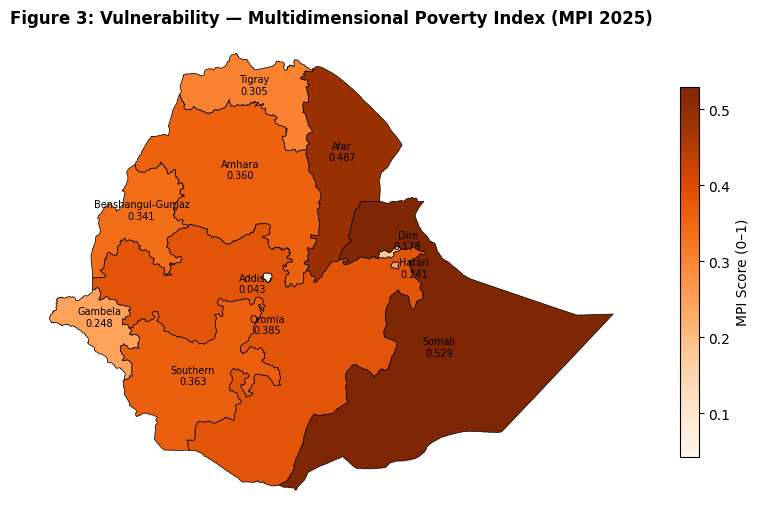

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

eth_adm1.plot(column='mpi_region', ax=ax, cmap='Oranges', legend=True,
              edgecolor='black', linewidth=0.5,
              legend_kwds={'label': 'MPI Score (0–1)', 'shrink': 0.6})

offsets = {
     'Dire Dawa':                       ( 0.5,  0.1),
    'Harari People':                   ( 0.5, -0.3),
    'Addis Abeba':                     (-0.4, -0.4),
    'Southern Nations, Nationalities': ( 0.0, -0.3),
}

for idx, row in eth_adm1.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ox, oy = offsets.get(row['Region'], (0, 0))
    ax.text(x + ox, y + oy,
            f"{row['Region'].split()[0]}\n{row['mpi_region']:.3f}",
            fontsize=7, ha='center', color='black')

ax.set_title('Figure 3: Vulnerability — Multidimensional Poverty Index (MPI 2025)',
             fontsize=12, fontweight='bold')
ax.set_axis_off()

In [73]:
print(eth_adm1[['Region', 'hazard_raw', 'pop_raw', 'cattle_raw', 'mpi_region']].to_string())
print(f"\nMissing values: {eth_adm1[['hazard_raw','pop_raw','cattle_raw','mpi_region']].isna().sum().to_dict()}")

                             Region  hazard_raw       pop_raw    cattle_raw  mpi_region
0                       Addis Abeba   25.895206  4.576825e+06  1.988258e+05    0.043310
1                              Afar   15.154066  2.132712e+06  3.338596e+06    0.486508
2                            Amhara   24.522410  2.628486e+07  1.556461e+07    0.360328
3                  Benshangul-Gumaz   21.072759  2.035390e+06  1.073278e+06    0.340938
4                         Dire Dawa   19.777164  7.536364e+05  1.967262e+05    0.177611
5                   Gambela Peoples   21.247582  6.766323e+05  4.182740e+05    0.248133
6                     Harari People   20.604380  6.488810e+05  7.650766e+04    0.241015
7                            Oromia   26.325169  5.409227e+07  2.528724e+07    0.384534
8                            Somali   25.067310  7.356134e+06  2.171667e+06    0.529493
9   Southern Nations, Nationalities   27.259280  2.724373e+07  1.234462e+07    0.362555
10                           Tig

In [74]:
def rescale_1_10(series):
    Xmin = series.min()
    Xmax = series.max()
    return 1 + (series - Xmin) * (10 - 1) / (Xmax - Xmin)

# Rescale all parameters
eth_adm1['hazard_scaled']  = rescale_1_10(eth_adm1['hazard_raw'])
eth_adm1['pop_scaled']     = rescale_1_10(eth_adm1['pop_raw'])
eth_adm1['cattle_scaled']  = rescale_1_10(eth_adm1['cattle_raw'])
eth_adm1['mpi_scaled']     = rescale_1_10(eth_adm1['mpi_region'])

# Check
print(eth_adm1[['Region', 'hazard_scaled', 'pop_scaled', 'cattle_scaled', 'mpi_scaled']].to_string())

                             Region  hazard_scaled  pop_scaled  cattle_scaled  mpi_scaled
0                       Addis Abeba       8.985837    1.661476       1.043666    1.000000
1                              Afar       1.000000    1.249881       2.164535    9.204283
2                            Amhara       7.965189    5.317163       6.529109    6.868489
3                  Benshangul-Gumaz       5.400437    1.233491       1.355838    6.509550
4                         Dire Dawa       4.437187    1.017641       1.042917    3.486122
5                   Gambela Peoples       5.530415    1.004673       1.122007    4.791595
6                     Harari People       5.052206    1.000000       1.000000    4.659819
7                            Oromia       9.305506   10.000000      10.000000    7.316579
8                            Somali       8.370311    2.129518       1.747953   10.000000
9   Southern Nations, Nationalities      10.000000    5.478639       5.379602    6.909719
10        

In [92]:
# Exposure
eth_adm1['exposure_scaled'] = (eth_adm1['pop_scaled'] + eth_adm1['cattle_scaled']) / 2

# Check
print(eth_adm1[['Region', 'exposure_scaled']])

                             Region  exposure_scaled
0                       Addis Abeba         1.352571
1                              Afar         1.707208
2                            Amhara         5.923136
3                  Benshangul-Gumaz         1.294665
4                         Dire Dawa         1.030279
5                   Gambela Peoples         1.063340
6                     Harari People         1.000000
7                            Oromia        10.000000
8                            Somali         1.938735
9   Southern Nations, Nationalities         5.429121
10                           Tigray         2.283986


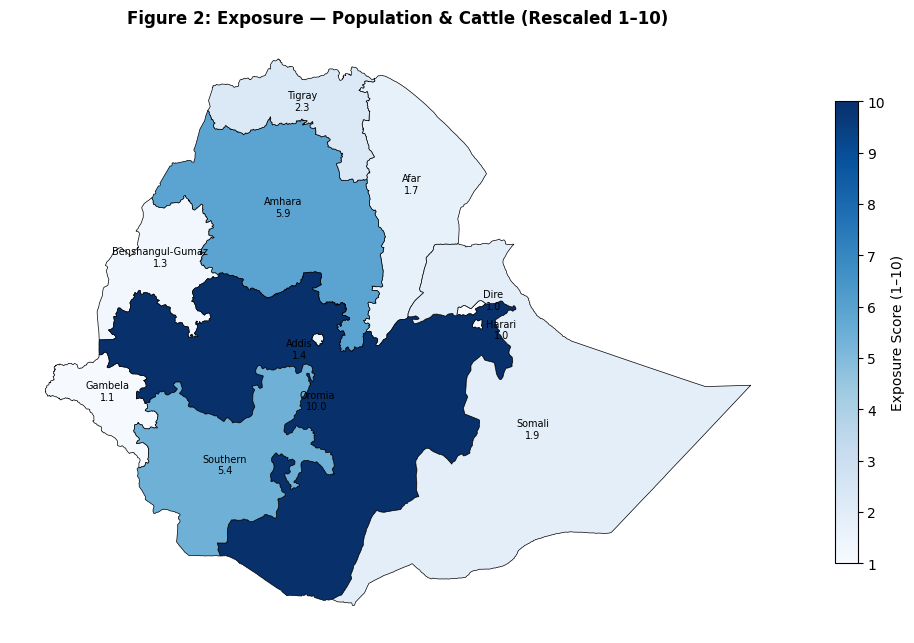

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

eth_adm1.plot(column='exposure_scaled', ax=ax, cmap='Blues', legend=True,
              edgecolor='black', linewidth=0.5,
              legend_kwds={'label': 'Exposure Score (1–10)', 'shrink': 0.6})

offsets = {
    'Dire Dawa':                       ( 0.5,  0),
    'Harari People':                   ( 0.5, -0.3),
    'Addis Abeba':                     (-0.4, -0.4),
    'Southern Nations, Nationalities': ( 0.0, -0.3),
}

for idx, row in eth_adm1.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ox, oy = offsets.get(row['Region'], (0, 0))
    ax.text(x + ox, y + oy,
            f"{row['Region'].split()[0]}\n{row['exposure_scaled']:.1f}",
            fontsize=7, ha='center', color='black')

ax.set_title('Figure 2: Exposure — Population & Cattle (Rescaled 1–10)',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/maps/02_exposure_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [93]:
# Risk Assessment
eth_adm1['risk_assessment'] = (eth_adm1['hazard_scaled'] * 
                           eth_adm1['exposure_scaled'] * 
                           eth_adm1['mpi_scaled'])

# Check
print(eth_adm1[['Region', 'hazard_scaled', 'exposure_scaled', 'mpi_scaled', 'risk_assessment']]
      .sort_values('risk_assessment', ascending=False)
      .to_string())


                             Region  hazard_scaled  exposure_scaled  mpi_scaled  risk_assessment
7                            Oromia       9.305506        10.000000    7.316579       680.844728
9   Southern Nations, Nationalities      10.000000         5.429121    6.909719       375.136997
2                            Amhara       7.965189         5.923136    6.868489       324.047724
8                            Somali       8.370311         1.938735   10.000000       162.278185
10                           Tigray       5.754863         2.283986    5.843823        76.811357
3                  Benshangul-Gumaz       5.400437         1.294665    6.509550        45.513179
5                   Gambela Peoples       5.530415         1.063340    4.791595        28.177997
6                     Harari People       5.052206         1.000000    4.659819        23.542368
4                         Dire Dawa       4.437187         1.030279    3.486122        15.936949
1                             

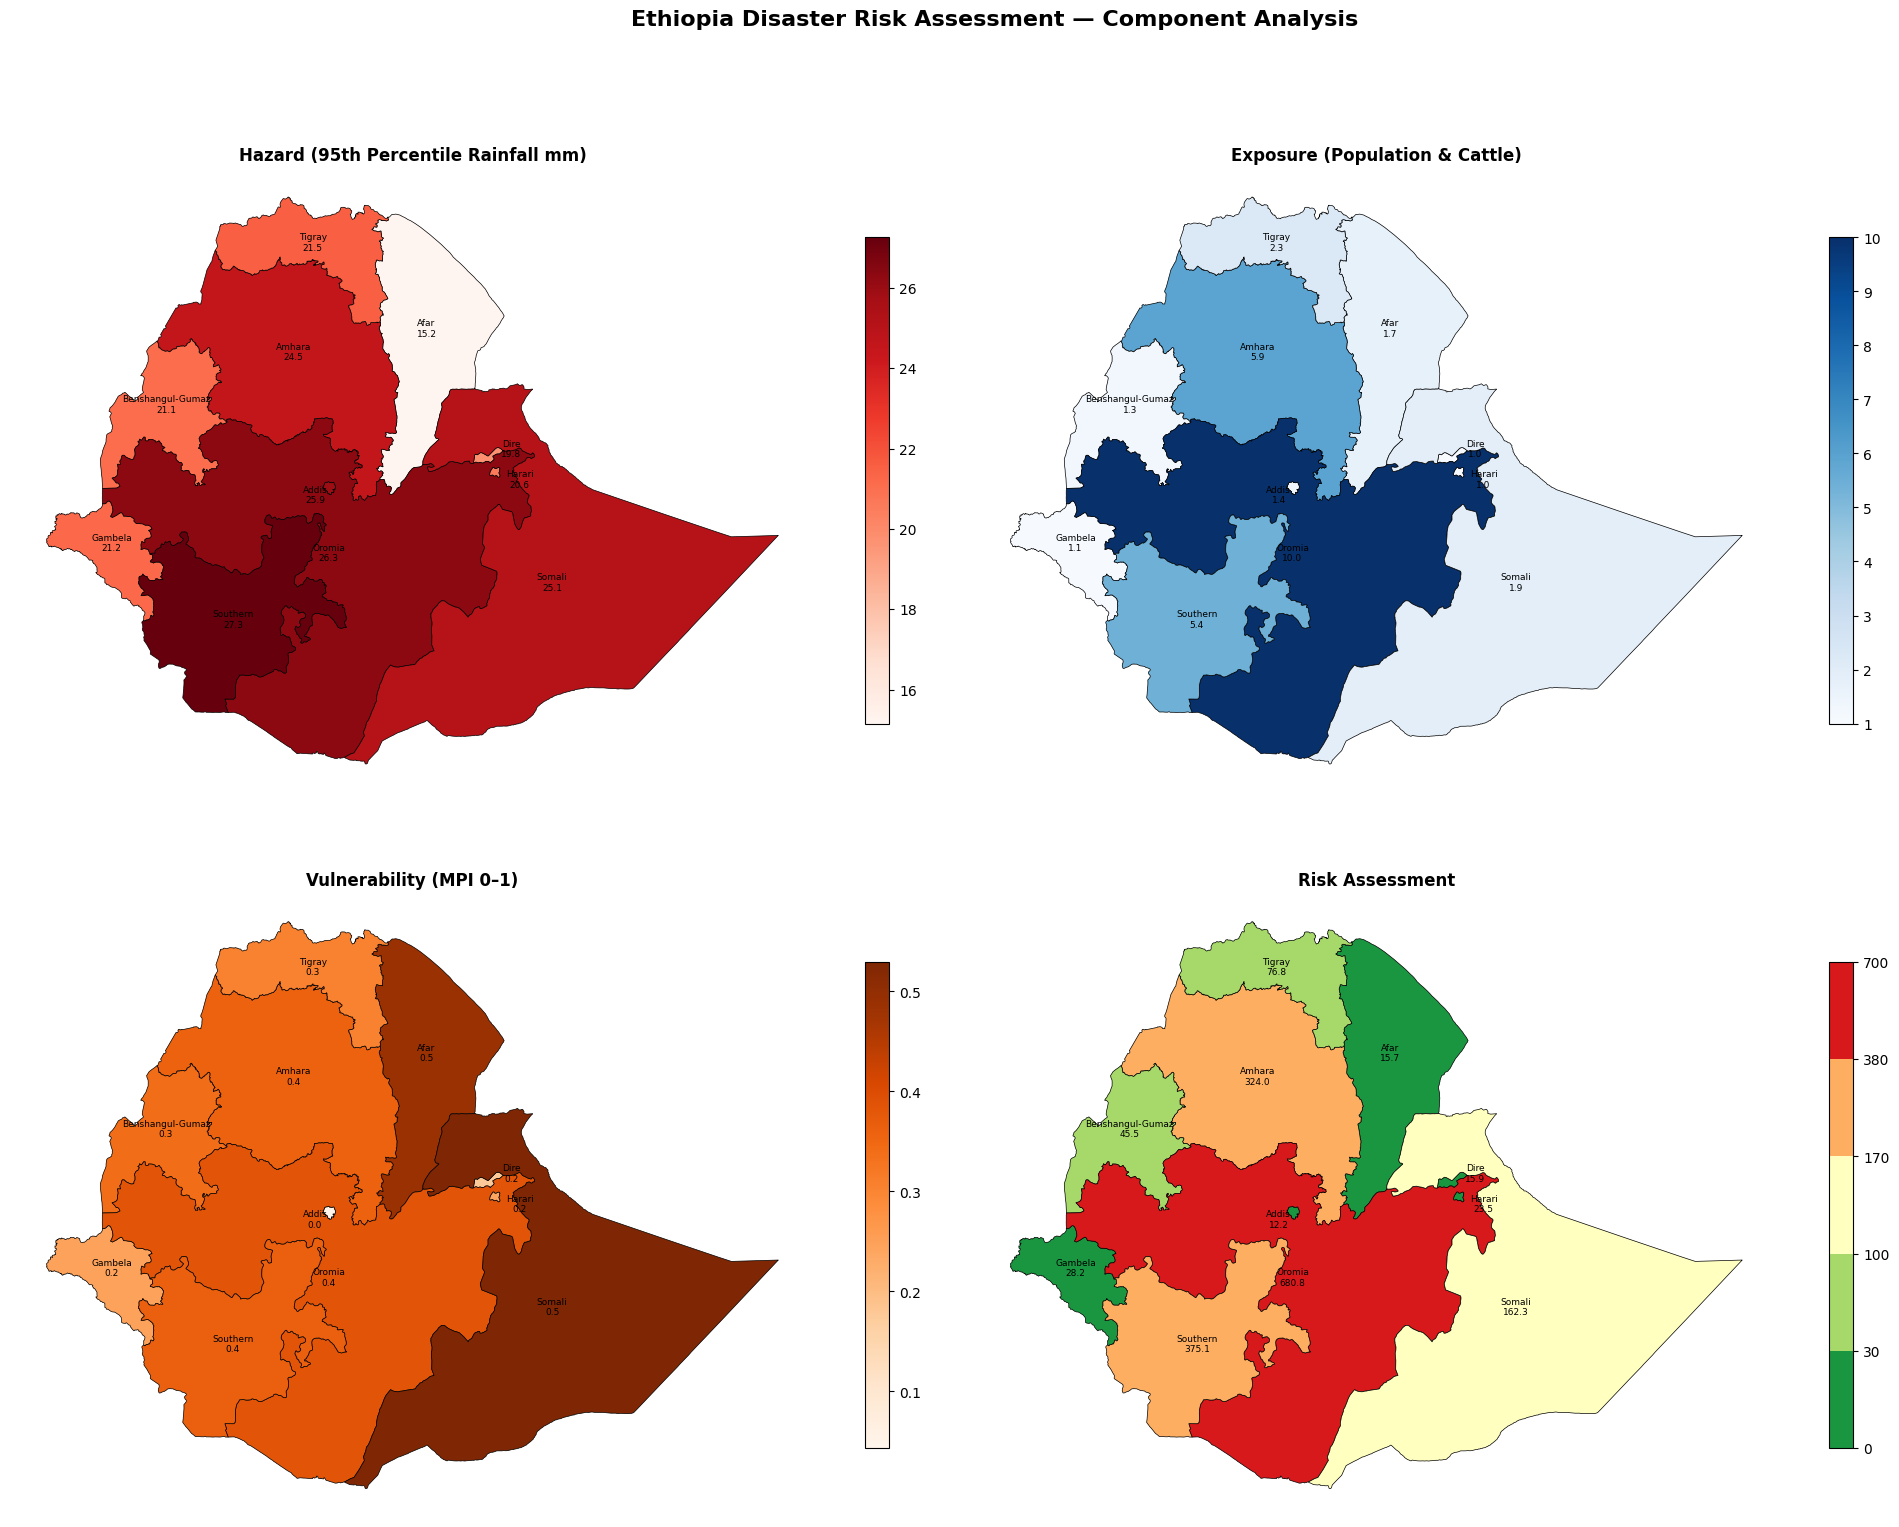

Comparison map saved.


In [117]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

risk_cmap = ListedColormap(['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'])
risk_norm = BoundaryNorm([0, 30, 100, 170, 380, 700], risk_cmap.N)

maps = [
    ('hazard_raw',      'Hazard (95th Percentile Rainfall mm)', 'Reds',    None),
    ('exposure_scaled', 'Exposure (Population & Cattle)',        'Blues',   None),
    ('mpi_region',      'Vulnerability (MPI 0–1)',               'Oranges', None),
    ('risk_assessment', 'Risk Assessment',                        risk_cmap, risk_norm),
]

offsets = {
    'Dire Dawa':                       ( 0.5,  0),
    'Harari People':                   ( 0.5, -0.3),
    'Addis Abeba':                     (-0.3, -0.3),
    'Southern Nations, Nationalities': ( 0.0, -0.3),
}

for ax, (col, title, cmap, norm) in zip(axes.flatten(), maps):
    eth_adm1.plot(column=col, ax=ax, cmap=cmap, norm=norm, legend=True,
                  edgecolor='black', linewidth=0.5,
                  legend_kwds={'shrink': 0.6})
    for idx, row in eth_adm1.iterrows():
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y
        ox, oy = offsets.get(row['Region'], (0, 0))
        ax.text(x + ox, y + oy,
                f"{row['Region'].split()[0]}\n{row[col]:.1f}",
                fontsize=6.5, ha='center', color='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Ethiopia Disaster Risk Assessment — Component Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/maps/05_component_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison map saved.')

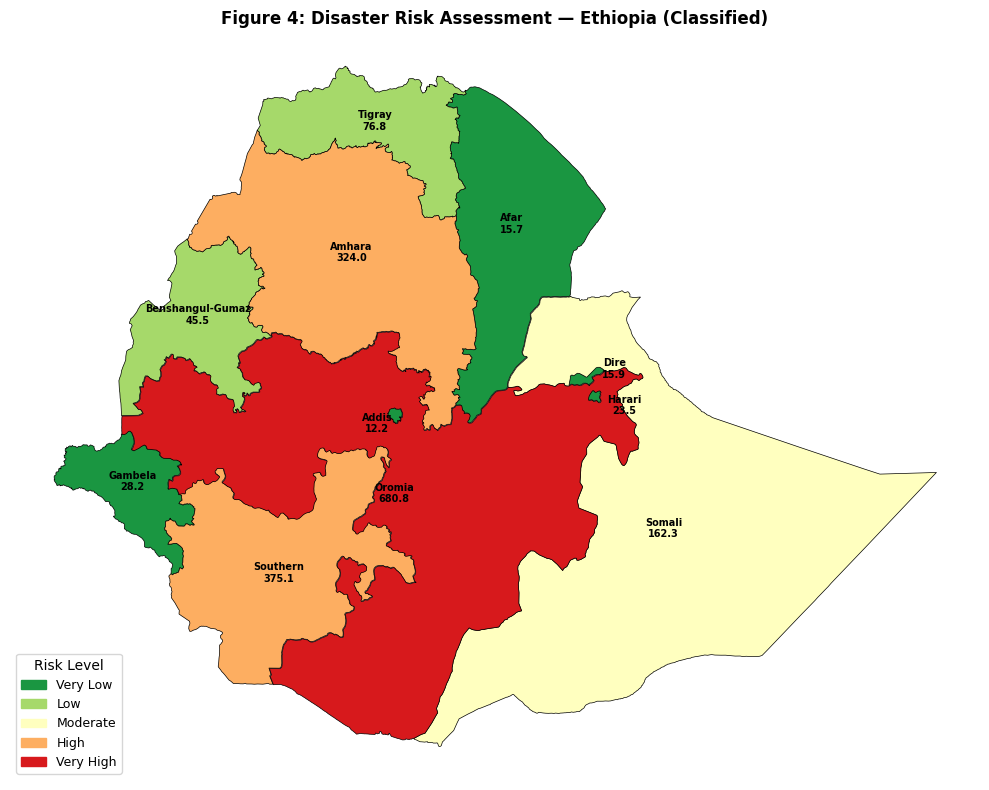

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for color, label in zip(colors, labels):
    subset = eth_adm1[eth_adm1['risk_class'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

offsets = {
    'Dire Dawa':                       ( 0.5,  0),
    'Harari People':                   ( 0.5, -0.3),
    'Addis Abeba':                     (-0.3, -0.3),
    'Southern Nations, Nationalities': ( 0.0, -0.3),
}

for idx, row in eth_adm1.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ox, oy = offsets.get(row['Region'], (0, 0))
    ax.text(x + ox, y + oy,
            f"{row['Region'].split()[0]}\n{row['risk_assessment']:.1f}",
            fontsize=7, ha='center', color='black', fontweight='bold')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, title='Risk Level', loc='lower left', fontsize=9)
ax.set_title('Figure 4: Disaster Risk Assessment — Ethiopia (Classified)',
             fontsize=12, fontweight='bold')

ax.set_axis_off()
plt.tight_layout()
plt.savefig('outputs/maps/04_risk_classified_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [128]:
import xarray as xr
import numpy as np
from rasterstats import zonal_stats
import pandas as pd

years = range(1991, 2026)
results = []

print('Extracting annual mean rainfall per region...')
for year in years:
    filepath = f'data/chirps/chirps-v2.0.{year}.days_p25.nc'
    ds = xr.open_dataset(filepath)
    
    # Annual total rainfall
    annual_total = ds['precip'].sum(dim='time')
    annual_total.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=True)
    annual_total.rio.write_crs('EPSG:4326', inplace=True)
    annual_total.rio.to_raster(f'data/chirps/temp_{year}.tif')
    ds.close()
    
    stats = zonal_stats(eth_adm1, f'data/chirps/temp_{year}.tif',
                        stats=['mean'], nodata=-9999)
    
    for i, row in eth_adm1.iterrows():
        results.append({
            'year': year,
            'region': row['Region'],
            'annual_rainfall': stats[i]['mean']
        })
    print(f'{year} done')

df_timeline = pd.DataFrame(results)
print(df_timeline.head())

Extracting annual mean rainfall per region...


ValueError: width and height must be > 0